# Kenya Coffee Research - Statistical Analysis
## Predicting Coffee Yield Variation Using Climate Data (1990-2024)

**Author:** Doreen Molly Wanjiru
**Dataset:** 35 years (1990-2024)
**Date:** June 2026

---

## Analysis Workflow

This notebook follows the following steps:
1. **Descriptive Statistics** - Understanding the data
2. **Exploratory Visualizations** - Identifying patterns
3. **Regression Assumptions Testing** - Validating modeling approach
4. **Regression Modeling** - Identifying significant variables
5. **Advanced Visualizations** - Communicating findings

---

## Setup & Data Loading

In [3]:
import sys
!{sys.executable} -m pip install scipy

print("SciPy installed successfully!")

SciPy installed successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [5]:
# setting up display and visualization settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS")
print("-"*45)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS
---------------------------------------------
Analysis Date: 2026-07-08 12:00


In [6]:
data_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/master_data_1990_2024.csv'
df = pd.read_csv(data_path)

print(f"\n Data loaded successfully!")
print(f"  Shape: {df.shape[0]} observations × {df.shape[1]} variables")
print(f"  Time period: {df['Year'].min()}-{df['Year'].max()}")
print(f"\nVariables in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


 Data loaded successfully!
  Shape: 35 observations × 10 variables
  Time period: 1990-2024

Variables in dataset:
  1. Year
  2. Area_Ha
  3. Production_Tonnes
  4. Yield_Kg_Ha
  5. Production_Value_1000USD
  6. Value_Unit
  7. Temperature
  8. Precipitation
  9. Humidity
  10. Solar_Radiation


In [7]:
print("\nFirst 10 rows:")
df.head(10)


First 10 rows:


,Year,Area_Ha,Production_Tonnes,Yield_Kg_Ha,Production_Value_1000USD,Value_Unit,Temperature,Precipitation,Humidity,Solar_Radiation
0,1990,153100.000,103900.000,678.600,425834,1000 USD,17.825,44.499,11.482,20.186
1,1991,155400.000,86400.000,556.000,354110,1000 USD,18.321,36.425,10.948,20.752
2,1992,153800.000,85300.000,554.600,349602,1000 USD,18.271,35.837,10.859,20.538
3,1993,158200.000,75100.000,474.700,307797,1000 USD,17.989,38.087,10.878,20.632
4,1994,158700.000,79900.000,503.500,327470,1000 USD,18.279,44.731,11.013,21.080
5,1995,160500.000,95400.000,594.400,390996,1000 USD,17.979,41.650,11.287,20.509
6,1996,177400.000,97976.000,552.300,401554,1000 USD,17.902,39.834,11.150,20.241
7,1997,176907.000,68642.000,388.000,281329,1000 USD,18.290,49.452,11.041,20.479
8,1998,178500.000,53715.000,300.900,220151,1000 USD,17.919,43.059,11.916,20.074
9,1999,170000.000,68100.000,400.600,279108,1000 USD,18.631,28.574,10.454,20.846


# Section 1: Descritpive Statistics

We will understand our data through:
1. **Summary statistics** (mean, median, SD, min, max)
2. **Distribution characteristics** (skewness, kurtosis)
3. **Variability measures** (coefficient of variation)
4. **Normality tests** (Shapiro-Wilk)
5. **Bivariate correlations** (relationships between variables)
6. **Temporal trends** (changes over time)

---
## 1.1: Defining Variable Groups

In [8]:
dependent_var = 'Yield_Kg_Ha'
independent_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
all_vars = [dependent_var] + independent_vars

print("Variable Structure:")
print(f"  Dependent variable (Y):     {dependent_var}")
print(f"  Independent variables (X):  {', '.join(independent_vars)}")

Variable Structure:
  Dependent variable (Y):     Yield_Kg_Ha
  Independent variables (X):  Temperature, Precipitation, Humidity, Solar_Radiation


## 1.2 Summary Statistics
Let's start with basic descriptive statistics for all key variables.

In [9]:
summary = df[all_vars].describe()

print("SUMMARY STATISTICS")
print("-"*20)
print(summary.round(2))

print("\n")
print("ADDITIONAL STATISTICS")
print("\n")
print(f"{'Variable':<20} {'Median':>10} {'Range':>12} {'IQR':>10}")
print("-"*60)

for var in all_vars:
    median = df[var].median()
    range_val = df[var].max() - df[var].min()
    iqr = df[var].quantile(0.75) - df[var].quantile(0.25)
    print(f"{var:<20} {median:>10.2f} {range_val:>12.2f} {iqr:>10.2f}")

SUMMARY STATISTICS
--------------------
       Yield_Kg_Ha  Temperature  Precipitation  Humidity  Solar_Radiation
count       35.000       35.000         35.000    35.000           35.000
mean       398.610       18.480         40.480    11.260           20.580
std        109.410        0.380         10.030     0.480            0.370
min        262.500       17.820         22.300    10.130           20.010
25%        311.150       18.280         35.990    10.990           20.280
50%        370.000       18.460         39.830    11.180           20.540
75%        462.200       18.760         44.620    11.500           20.840
max        678.600       19.200         66.520    12.580           21.320


ADDITIONAL STATISTICS


Variable                 Median        Range        IQR
------------------------------------------------------------
Yield_Kg_Ha              370.00       416.10     151.05
Temperature               18.46         1.38       0.48
Precipitation             39.83        

#### Intepretation:

Based on the data, we can see that our dependent variable(yield) ranges between 262.5 kg/ha and 678.6 kg/ha (a 2.6x difference). The mean(398.61) is also slightly right-skewed since it is greater than the median(370.00). 

Precipitation is the independent variable that has the widest range: 22.3 - 66.5 mm (nearly a 3x difference). It might be the strongest predictor of yield due to its high variability. 

Temperature, humidity and solar radiation on the other hand have limited variations hence have limited standalone predictive power. 

## 1.3 Distribution Characteristics

**Skewness** to measure asymmetry:
- **0** = perfectly symmetric
- **-ve** = left-skewed
- **+ve** = right-skewed
- |skewness| < 0.5 is fairly symmetric

**Kurtosis** to measure tail heaviness:
- **0** = normal distribution
- **+ve** = heavy tails (more outliers)
- **-ve** = light tails (fewer outliers)


In [10]:
print("DISTRIBUTION CHARACTERISTICS")
print("\n")
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'Skewness':>10} {'Kurtosis':>10}")
print("-"*65)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    skew = stats.skew(df[var])
    kurt = stats.kurtosis(df[var])
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {skew:>10.3f} {kurt:>10.3f}")

print("\nInterpretation Guide:")
print("  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)")
print("  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)")

DISTRIBUTION CHARACTERISTICS


Variable                   Mean    Std Dev   Skewness   Kurtosis
-----------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      0.791     -0.308
Temperature               18.48       0.38     -0.020     -0.812
Precipitation             40.48      10.03      0.704      0.442
Humidity                  11.26       0.48      0.477      0.946
Solar_Radiation           20.58       0.37      0.380     -0.669

Interpretation Guide:
  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)
  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)


**Yield_Kg_Ha:**
Distribution has a longer tail toward high yields(skewness = 0.791); most observations cluster at lower-to-average values with some high performers.
Fewer extreme values than normal distribution (Kurtosis = -0.308); yields are relatively concentrated around the mean without many outliers.
Variable may benefit from log transformation if used in linear regression to normalize distribution.

**Precipitation:**
Most observations (skewness = 0.704) are at lower-to-moderate precipitation levels with some notably high rainfall events.
Modest presence of extreme precipitation values(Kurtosis = 0.442); occasional heavy rainfall periods.
Asymmetric distribution. May consider square root or log transformation to normalize for certain models.

**Humidity:**
Nearly symmetric with values evenly distributed around the mean.
Heavy-tailed (kurtosis = 0.946); more extreme values than normal distribution despite narrow range.
Despite low variance, frequent extremes may indicate threshold effects worth investigating.

**Temperature and Solar Radiation:**
Both are symmetric, with values evenly distributed around the mean. They have more uniform distribution without many extremes. 






## 1.4 Coefficient of Variation (CV)

The CV measures relative variability (standard deviation as a percentage of the mean).

**Interpretation:**
- **CV < 15%** = Low variability (stable)
- **CV 15-30%** = Moderate variability
- **CV > 30%** = High variability (volatile)

This is useful for comparing variability across variables with different units.

In [11]:
print("COEFFICIENT OF VARIATION (CV)")
print("-"*30)
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'CV %':>10} {'Interpretation':>15}")
print("-"*70)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    cv = (std/mean) * 100

    if cv < 15:
        interp = "Low"
    elif cv < 30:
        interp = "Moderate"
    else:
        interp = "High"
    
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {cv:>10.2f} {interp:>15}")


COEFFICIENT OF VARIATION (CV)
------------------------------
Variable                   Mean    Std Dev       CV %  Interpretation
----------------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      27.45        Moderate
Temperature               18.48       0.38       2.04             Low
Precipitation             40.48      10.03      24.78        Moderate
Humidity                  11.26       0.48       4.30             Low
Solar_Radiation           20.58       0.37       1.78             Low


## 1.5 Normality Tests

We check if variables follow a normal distribution.

**Shapiro-Wilk Test:**
- **H₀** (null hypothesis): Data is normally distributed
- **H₁** (alternative): Data is NOT normally distributed
- **Decision rule**: If p-value > 0.05, we accept H₀ (data is normal)


In [12]:
print("NORMALITY TESTS (Shapiro-Wilk)")
print("-"*30)
print(f"{'Variable':<20} {'W-statistic':>12} {'p-value':>10} {'Normal?':>12}")
print("-"*58)

for var in all_vars:
    stat, p_value = stats.shapiro(df[var])
    is_normal = "Yes ✓" if p_value > 0.05 else "No ✗"
    print(f"{var:<20} {stat:>12.4f} {p_value:>10.4f} {is_normal:>12}")

print("\nInterpretation:")
print("  If p > 0.05: Variable is normally distributed ✓")
print("  If p < 0.05: Variable deviates from normality ✗")

NORMALITY TESTS (Shapiro-Wilk)
------------------------------
Variable              W-statistic    p-value      Normal?
----------------------------------------------------------
Yield_Kg_Ha                0.9165     0.0113         No ✗
Temperature                0.9684     0.4003        Yes ✓
Precipitation              0.9428     0.0682        Yes ✓
Humidity                   0.9670     0.3651        Yes ✓
Solar_Radiation            0.9589     0.2113        Yes ✓

Interpretation:
  If p > 0.05: Variable is normally distributed ✓
  If p < 0.05: Variable deviates from normality ✗


Shapiro-Wilk tests reveal that Yield_Kg_Ha significantly deviates from normality, which is consistent with its moderate right skewness (0.791). All predictor variables pass normality tests. 

This is not a problem for now since OLS regression assumes RESIDUALS are normal, not the variables themselves.

/var/folders/20/758jl_4d73v071lxtlj_nlfc0000gn/T/ipykernel_13436/3077405924.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[2].boxplot(df['Yield_Kg_Ha'], vert=True, patch_artist=True)


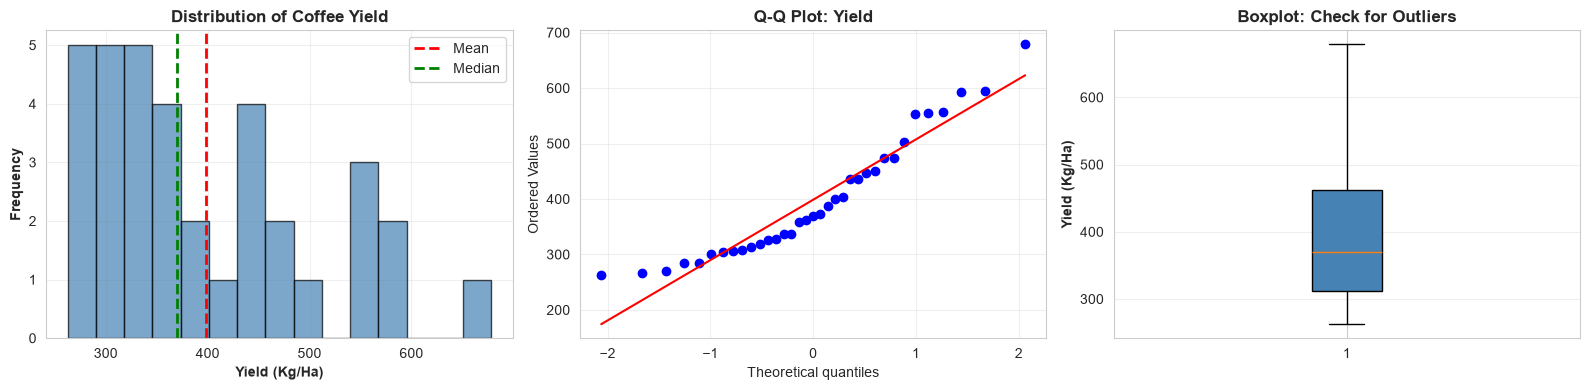

Yield Skewness: 0.791
  → Right-skewed (tail extends to the right)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Yield_Kg_Ha'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Yield_Kg_Ha'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['Yield_Kg_Ha'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Yield (Kg/Ha)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Coffee Yield', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(df['Yield_Kg_Ha'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Yield', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Boxplot
bp = axes[2].boxplot(df['Yield_Kg_Ha'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
axes[2].set_ylabel('Yield (Kg/Ha)', fontweight='bold')
axes[2].set_title('Boxplot: Check for Outliers', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/yield_normality_check.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Check skewness
skewness = stats.skew(df['Yield_Kg_Ha'])
print(f"Yield Skewness: {skewness:.3f}")
if skewness > 0:
    print("  → Right-skewed (tail extends to the right)")
elif skewness < 0:
    print("  → Left-skewed (tail extends to the left)")

The coffee yield shows mild right-skewness (0.791) and fails the Shapiro-Wilk normality test (p = 0.011).

We will use original yield (Kg/Ha) without transformation, a Level-Level Model.

This is because the skewness < 1.0 is acceptable for OLS with n=35, and coefficients will be directly interpretable for agricultural policy.


In [14]:
#Variables for modeling
df['Yield_Model'] = df['Yield_Kg_Ha']  # Primary: Original scale
df['Yield_Log'] = np.log(df['Yield_Kg_Ha'])  # Sensitivity check

print("✓ Primary model: Level-Level (Original Yield)")
print("✓ Sensitivity check: Log-Level (saved for Appendix)")

✓ Primary model: Level-Level (Original Yield)
✓ Sensitivity check: Log-Level (saved for Appendix)


## 1.6 Bivariate Correlations

How is each climate variable related to coffee yield?

**Pearson Correlation Coefficient (r):**
- Range: -1 to +1
- **r > 0**: Positive relationship (as X increases, Y increases)
- **r < 0**: Negative relationship (as X increases, Y decreases)
- **|r| < 0.3**: Weak correlation
- **|r| 0.3-0.7**: Moderate correlation
- **|r| > 0.7**: Strong correlation

**Significance levels:**
- *** p < 0.001 (highly significant)
- ** p < 0.01 (significant)
- * p < 0.05 (marginally significant)
- ns: not significant

In [15]:
print("="*80)
print("CORRELATIONS WITH YIELD")
print("="*80)
print(f"{'Variable':<20} {'Pearson r':>12} {'p-value':>10} {'Strength':>12} {'Significance':>15}")
print("-"*79)

for var in independent_vars:
    r, p_val = stats.pearsonr(df[dependent_var], df[var])
    
    # Determine strength
    if abs(r) < 0.3:
        strength = "Weak"
    elif abs(r) < 0.7:
        strength = "Moderate"
    else:
        strength = "Strong"
    
    # Determine significance
    if p_val < 0.001:
        sig = "*** (p<0.001)"
    elif p_val < 0.01:
        sig = "**  (p<0.01)"
    elif p_val < 0.05:
        sig = "*   (p<0.05)"
    else:
        sig = "ns  (p≥0.05)"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {strength:>12} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Higher climate variable → Higher yield")
print("  Negative r: Higher climate variable → Lower yield")

CORRELATIONS WITH YIELD
Variable                Pearson r    p-value     Strength    Significance
-------------------------------------------------------------------------------
Temperature                -0.406     0.0155     Moderate    *   (p<0.05)
Precipitation               0.041     0.8154         Weak    ns  (p≥0.05)
Humidity                   -0.153     0.3805         Weak    ns  (p≥0.05)
Solar_Radiation             0.097     0.5783         Weak    ns  (p≥0.05)

Interpretation:
  Positive r: Higher climate variable → Higher yield
  Negative r: Higher climate variable → Lower yield


Temperature emerges as the only significant predictor (r = -0.406, p = 0.016), exhibiting a moderate negative relationship with yield. 

Surprisingly, precipitation shows virtually no linear correlation (r = 0.041, p = 0.815), contradicting initial expectations based on its high variability. This suggests precipitation may have non-linear effects, threshold relationships, or interact with other variables. 

Humidity and solar radiation show weak, non-significant correlations as anticipated given their limited variance.

## 1.7 Temporal Trends

Are variables increasing or decreasing over time (1990-2024)?

This helps us understand the climate change patterns as well as the long-term yield trends. It also helps us decide whether we need to account for time in our models.

In [16]:
print("TEMPORAL TRENDS (Correlation with Year)")
print("-"*40)
print(f"{'Variable':<20} {'Trend (r)':>12} {'p-value':>10} {'Direction':>15} {'Significant?':>15}")
print("-"*76)

for var in all_vars:
    r, p_val = stats.pearsonr(df['Year'], df[var])
    
    # Determine direction
    if r > 0.1:
        direction = "Increasing ↑"
    elif r < -0.1:
        direction = "Decreasing ↓"
    else:
        direction = "Stable →"
    
    # Significance
    sig = "Yes" if p_val < 0.05 else "No"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {direction:>15} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Variable increasing over time")
print("  Negative r: Variable decreasing over time")
print("  |r| < 0.1: Variable relatively stable")

TEMPORAL TRENDS (Correlation with Year)
----------------------------------------
Variable                Trend (r)    p-value       Direction    Significant?
----------------------------------------------------------------------------
Yield_Kg_Ha                -0.434     0.0092    Decreasing ↓             Yes
Temperature                 0.323     0.0581    Increasing ↑              No
Precipitation               0.435     0.0090    Increasing ↑             Yes
Humidity                    0.577     0.0003    Increasing ↑             Yes
Solar_Radiation            -0.081     0.6424        Stable →              No

Interpretation:
  Positive r: Variable increasing over time
  Negative r: Variable decreasing over time
  |r| < 0.1: Variable relatively stable


Both dependent and independent variables show significant time trends:
- Yield **declining** (r=-0.434, p=0.009)
- Precipitation **increasing** (r=0.435, p=0.009)  
- Humidity **increasing** (r=0.577, p<0.001)

There is a risk of **spurious correlation** whereby variables may correlate simply because both are trending over time, not due to causal relationship.

We will have to control for temporal trends in regression by adding **Year** as a control variable.

# Section 2: Exploratory Visualizations

## Objectives:
1. Visualize temporal trends in yield and climate variables
2. Examine relationships between climate and yield
3. Identify patterns, outliers, and non-linearities
4. Create publication-quality figures

---

## 2.1 Time Series: Coffee Yield Over Time

✓ Saved: 02_yield_timeseries.png


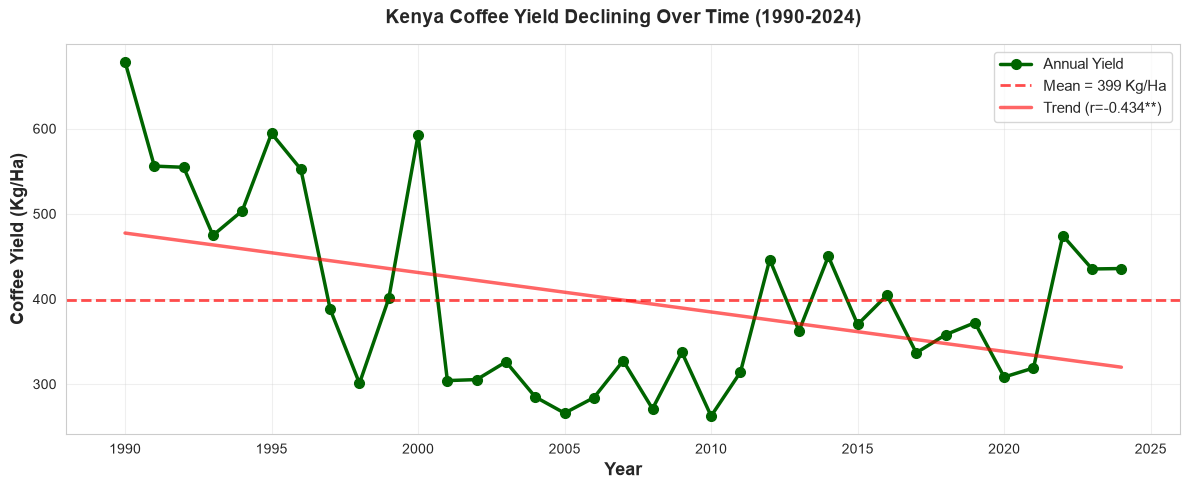


Yield Trend Analysis:
  • Average decline: -4.6 Kg/Ha per year
  • Total decline (1990-2024): -158 Kg/Ha (-23.2%)
  • Correlation with Year: r = -0.434 (p = 0.0092)


In [17]:
# 2.1 Time Series of Yield (showing the decline)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot yield over time
ax.plot(df['Year'], df['Yield_Kg_Ha'], marker='o', linewidth=2.5, 
        markersize=7, color='darkgreen', label='Annual Yield')

# Add mean line
mean_yield = df['Yield_Kg_Ha'].mean()
ax.axhline(mean_yield, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Mean = {mean_yield:.0f} Kg/Ha')

# Add trend line
z = np.polyfit(df['Year'], df['Yield_Kg_Ha'], 1)
p = np.poly1d(z)
ax.plot(df['Year'], p(df['Year']), "r-", linewidth=2.5, 
        alpha=0.6, label=f'Trend (r={stats.pearsonr(df["Year"], df["Yield_Kg_Ha"])[0]:.3f}**)')

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Coffee Yield (Kg/Ha)', fontsize=13, fontweight='bold')
ax.set_title('Kenya Coffee Yield Declining Over Time (1990-2024)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1988, 2026)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_yield_timeseries.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_yield_timeseries.png")
plt.show()

# Statistics
slope = z[0]
decline_total = slope * 34  # 1990 to 2024
print(f"\nYield Trend Analysis:")
print(f"  • Average decline: {slope:.1f} Kg/Ha per year")
print(f"  • Total decline (1990-2024): {decline_total:.0f} Kg/Ha ({(decline_total/df['Yield_Kg_Ha'].iloc[0])*100:.1f}%)")
print(f"  • Correlation with Year: r = {stats.pearsonr(df['Year'], df['Yield_Kg_Ha'])[0]:.3f} (p = {stats.pearsonr(df['Year'], df['Yield_Kg_Ha'])[1]:.4f})")

### Figure 1: Coffee Yield Decline (1990-2024)

Coffee yield in Kenya declined significantly over the study period. The downward trend is statistically significant (r = -0.434, p = 0.009), with an average decline of 4.6 Kg/Ha per year.

**Key Observations:**
- Sharp decline from 1990-1999 (679 → 401 Kg/Ha)
- Brief recovery 1999-2000
- Continued decline 2000-2024
- High year-to-year variability might suggest climate shocks

The consistent long-term decline indicates systematic factors beyond normal climate variability, warranting investigation of climate change impacts and other structural changes in Kenya's coffee sector.

## 2.2 Climate Variables: Temporal Trends
Visualizing the climate changes that coincide with yield decline.

✓ Saved: 02_climate_timeseries.png


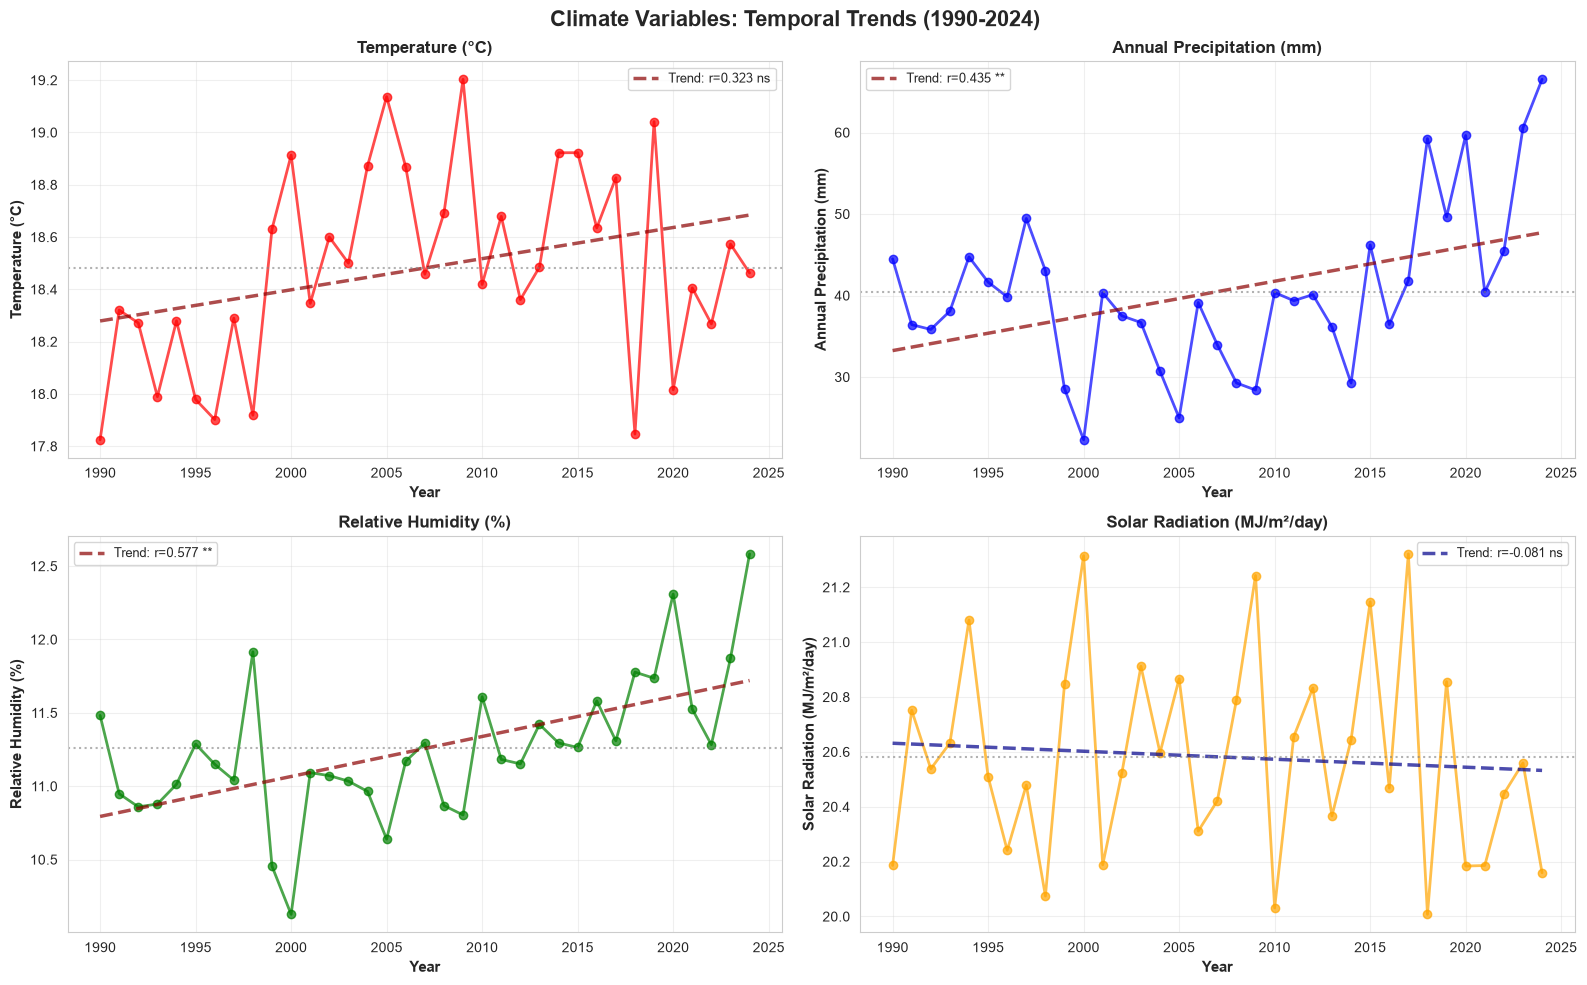


Climate Trends Summary:
  • Temperature       :    ↑ Increasing (r= 0.323) (ns)
  • Precipitation     :    ↑ Increasing (r= 0.435) **
  • Humidity          :    ↑ Increasing (r= 0.577) **
  • Solar_Radiation   :    ↓ Decreasing (r=-0.081) (ns)


In [18]:
# 2.2 Climate variables over time (4-panel plot)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Climate Variables: Temporal Trends (1990-2024)', 
             fontsize=16, fontweight='bold')

climate_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
colors = ['red', 'blue', 'green', 'orange']
titles = ['Temperature (°C)', 'Annual Precipitation (mm)', 
          'Relative Humidity (%)', 'Solar Radiation (MJ/m²/day)']

for idx, (var, color, title) in enumerate(zip(climate_vars, colors, titles)):
    ax = axes[idx//2, idx%2]
    
    # Plot data
    ax.plot(df['Year'], df[var], marker='o', linewidth=2, 
            markersize=6, color=color, alpha=0.7)
    
    # Add trend line
    z = np.polyfit(df['Year'], df[var], 1)
    p = np.poly1d(z)
    r, p_val = stats.pearsonr(df['Year'], df[var])
    
    trend_color = 'darkred' if r > 0 else 'darkblue'
    sig = '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    ax.plot(df['Year'], p(df['Year']), "--", linewidth=2.5, 
            color=trend_color, alpha=0.7, 
            label=f'Trend: r={r:.3f} {sig}')
    
    # Add mean line
    ax.axhline(df[var].mean(), color='gray', linestyle=':', 
               linewidth=1.5, alpha=0.6)
    
    # Formatting
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_climate_timeseries.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_climate_timeseries.png")
plt.show()

# Summary
print("\nClimate Trends Summary:")
for var in climate_vars:
    r, p_val = stats.pearsonr(df['Year'], df[var])
    direction = "↑ Increasing" if r > 0 else "↓ Decreasing"
    sig = "**" if p_val < 0.01 else "*" if p_val < 0.05 else "(ns)"
    print(f"  • {var:<18}: {direction:>15} (r={r:>6.3f}) {sig}")

### Figure 2: Climate Variable Trends (1990-2024)

Despite precipitation and humidity **increasing**, coffee yield is **declining**. This finding could suggest that:
1. Temperature stress or disease pressure may dominate
2. Rainfall timing/distribution matters more than total amount
3. There could be interactions between climate variables (e.g., high temp + high humidity could lead to disease)
4. There could be non-climate factors contributing to decline

Simple bivariate relationships are insufficient. We need to perform multivariate regression.

## 2.3 Climate-Yield Relationships
Scatter plots showing how each climate variable relates to coffee yield.

✓ Saved: 02_scatter_climate_yield.png


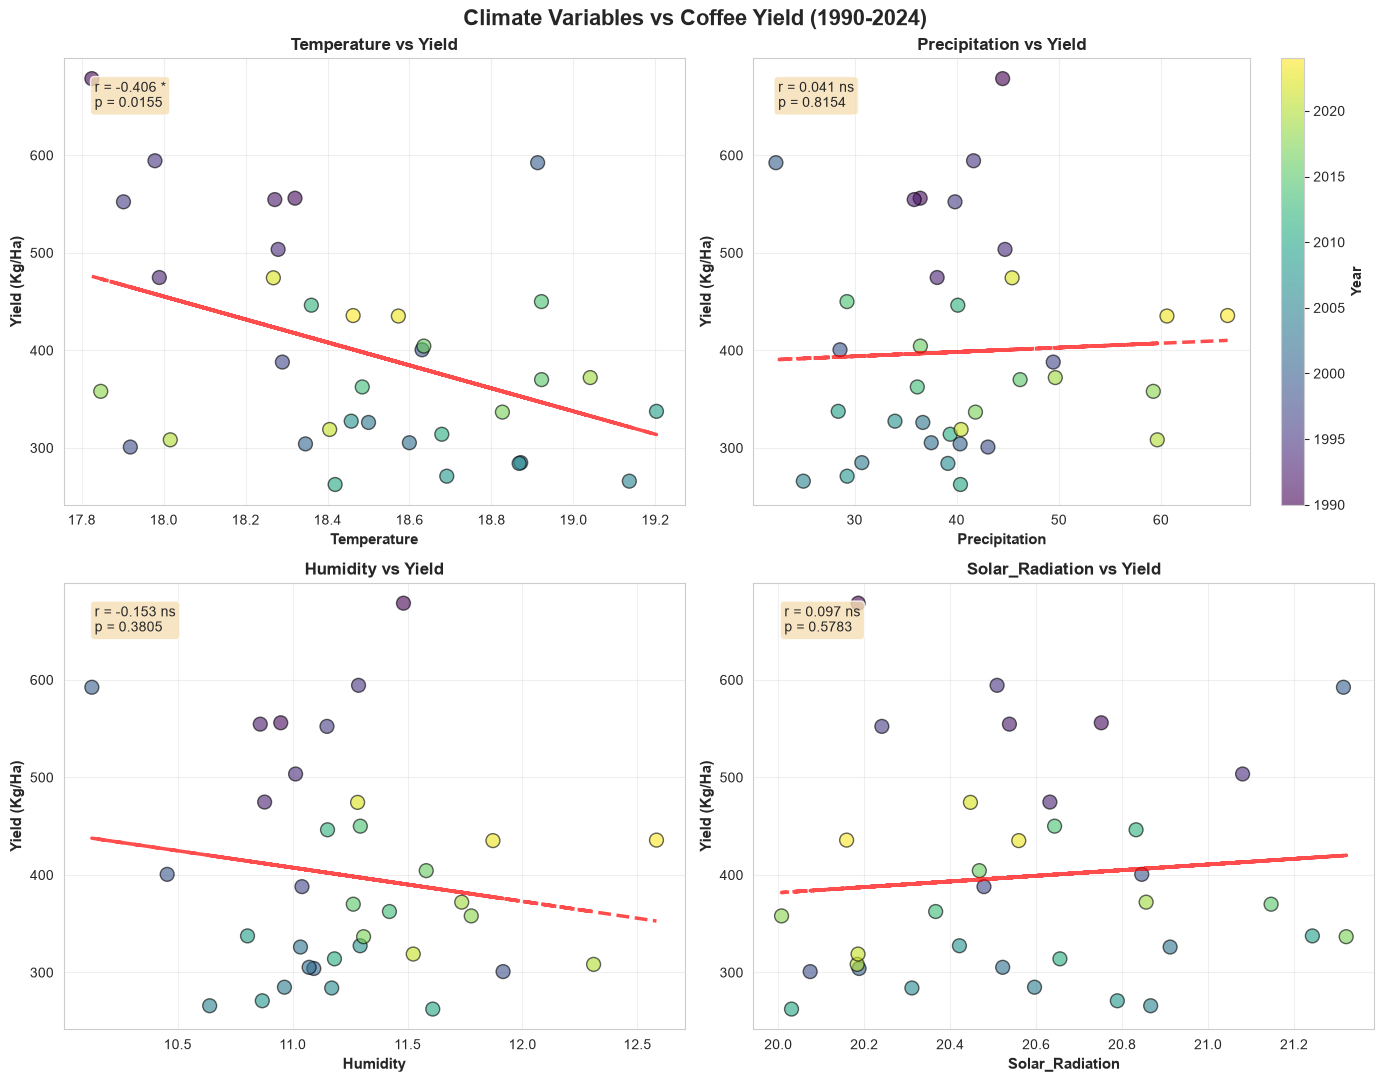


Visual Insights:
  • Color gradient shows time progression (yellow = recent years)
  • Temperature shows clearest negative relationship
  • Other variables show weaker/no linear patterns
  • Time confounding visible: recent years (yellow) cluster differently


In [19]:
# 2.3 Scatter plots: Climate vs Yield

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Climate Variables vs Coffee Yield (1990-2024)', 
             fontsize=16, fontweight='bold')

for idx, var in enumerate(independent_vars):
    ax = axes[idx//2, idx%2]
    
    # Scatter plot
    scatter = ax.scatter(df[var], df['Yield_Kg_Ha'], 
                        s=100, alpha=0.6, edgecolors='black', 
                        linewidth=1, c=df['Year'], cmap='viridis')
    
    # Add colorbar for year
    if idx == 1:  # Top right
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Year', fontsize=10, fontweight='bold')
    
    # Regression line
    z = np.polyfit(df[var], df['Yield_Kg_Ha'], 1)
    p = np.poly1d(z)
    ax.plot(df[var], p(df[var]), "r--", linewidth=2.5, alpha=0.7)
    
    # Calculate correlation
    r, p_val = stats.pearsonr(df[var], df['Yield_Kg_Ha'])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    # Add stats box
    textstr = f'r = {r:.3f} {sig}\np = {p_val:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Formatting
    ax.set_xlabel(var, fontsize=11, fontweight='bold')
    ax.set_ylabel('Yield (Kg/Ha)', fontsize=11, fontweight='bold')
    ax.set_title(f'{var} vs Yield', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_scatter_climate_yield.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_scatter_climate_yield.png")
plt.show()

# Key finding
print("\nVisual Insights:")
print("  • Color gradient shows time progression (yellow = recent years)")
print("  • Temperature shows clearest negative relationship")
print("  • Other variables show weaker/no linear patterns")
print("  • Time confounding visible: recent years (yellow) cluster differently")

### Figure 3: Climate-Yield Relationships

Scatter plots reveal varying strength of relationships between climate variables and coffee yield. Temperature is the only statistically significant variable with a moderate negative correlation (r = -0.406, p = 0.016*). Higher temperatures are associated with lower yields which is consistent with coffee physiology (optimal 15-24°C).


Temperature emerges as the primary climate driver in bivariate analysis. However, temporal trends visible in color gradients suggest spurious correlation risk - must control for time in regression models.

## 2.6 Correlation Matrix
Visual summary of all variable relationships.

✓ Saved: 02_correlation_heatmap.png


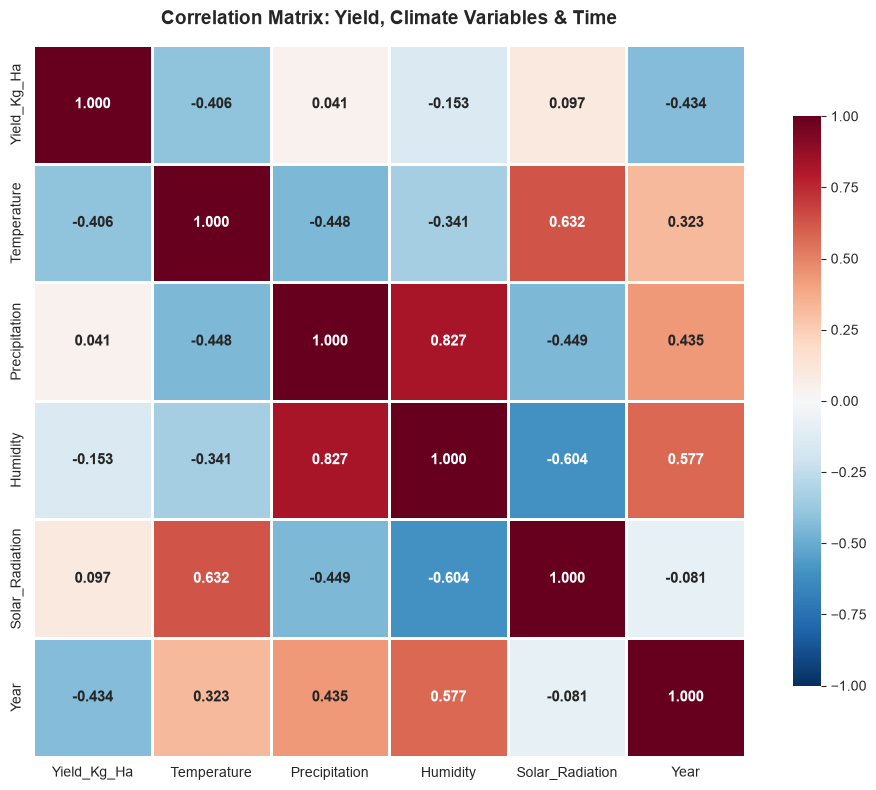


Key Correlations with Yield:
--------------------------------
  Temperature       : r =  -0.406
  Precipitation     : r =   0.041
  Humidity          : r =  -0.153
  Solar_Radiation   : r =   0.097
  Year              : r =  -0.434

Key Correlations Among Predictors (Multicollinearity Check):
------------------------------------------------------------
  Temp × Humidity    : r =  -0.341
  Temp × Solar       : r =   0.632
  Precip × Humidity  : r =   0.827


In [20]:
# 2.6 Correlation heatmap

# Select variables for correlation
corr_vars = ['Yield_Kg_Ha', 'Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation', 'Year']
corr_matrix = df[corr_vars].corr()

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', 
            cmap='RdBu_r', center=0, 
            square=True, linewidths=2, 
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-1, vmax=1)

plt.title('Correlation Matrix: Yield, Climate Variables & Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_correlation_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_correlation_heatmap.png")
plt.show()

# Highlight key correlations
print("\nKey Correlations with Yield:")
print("-"*32)
for var in ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation', 'Year']:
    r = corr_matrix.loc['Yield_Kg_Ha', var]
    print(f"  {var:<18}: r = {r:>7.3f}")

print("\nKey Correlations Among Predictors (Multicollinearity Check):")
print("-"*60)
print(f"  Temp × Humidity    : r = {corr_matrix.loc['Temperature', 'Humidity']:>7.3f}")
print(f"  Temp × Solar       : r = {corr_matrix.loc['Temperature', 'Solar_Radiation']:>7.3f}")
print(f"  Precip × Humidity  : r = {corr_matrix.loc['Precipitation', 'Humidity']:>7.3f}")

### Figure 4: Correlation Matrix

Multicollinearity detected between Precipitation and Humidity (r = 0.827).

We may need to drop one variable or test separately to avoid unstable coefficient estimates.

Only Temperature shows a meaningful correlation (r = -0.406).



✓ Saved: 02_distributions.png


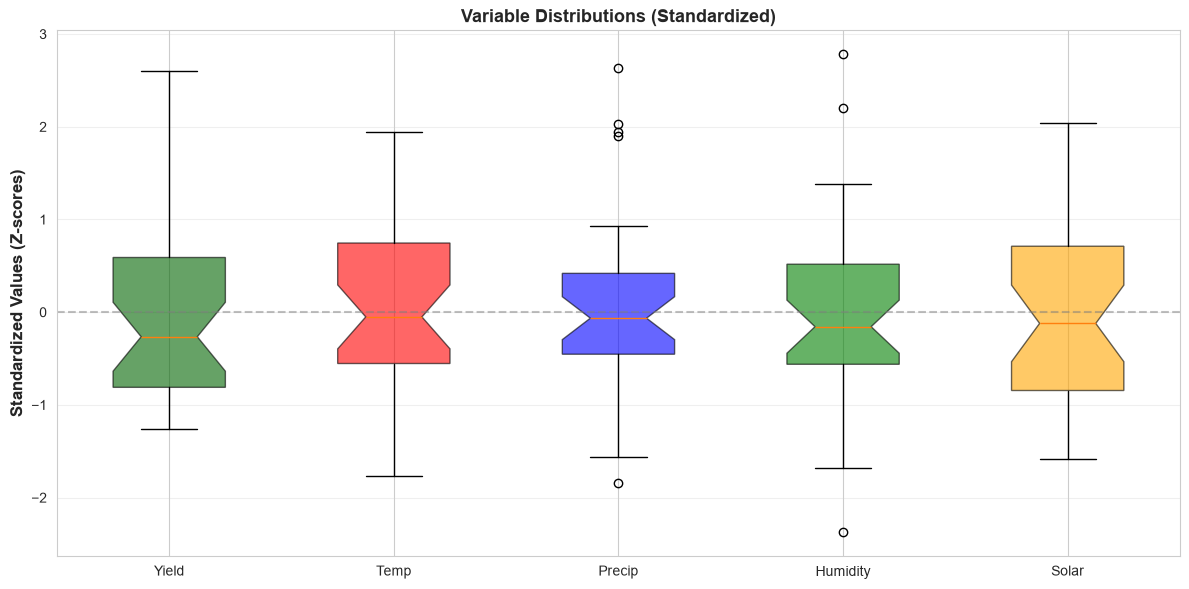


Outliers (>3 SD):
  Yield_Kg_Ha: None
  Temperature: None
  Precipitation: None
  Humidity: None
  Solar_Radiation: None


In [21]:
# 2.7 Box plots - check for outliers

from scipy.stats import zscore

vars_to_plot = ['Yield_Kg_Ha', 'Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']

fig, ax = plt.subplots(figsize=(12, 6))

# Standardize for comparison
df_std = df[vars_to_plot].apply(zscore)

# Box plot
bp = ax.boxplot([df_std[var] for var in vars_to_plot],
                 patch_artist=True,
                 notch=True)

# Set labels
ax.set_xticklabels(['Yield', 'Temp', 'Precip', 'Humidity', 'Solar'])

# Color
colors = ['darkgreen', 'red', 'blue', 'green', 'orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Standardized Values (Z-scores)', fontsize=12, fontweight='bold')
ax.set_title('Variable Distributions (Standardized)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_distributions.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_distributions.png")
plt.show()

# Check outliers
print("\nOutliers (>3 SD):")
for var in vars_to_plot:
    z = np.abs(zscore(df[var]))
    outliers = df[z > 3]['Year'].values
    if len(outliers) > 0:
        print(f"  {var}: Years {outliers}")
    else:
        print(f"  {var}: None")

### Figure 5: Variable Distributions

There were no extreme outliers detected (>3 SD). Mild outliers visible in precipitation and humidity represent natural climate variability, not data errors.

The data quality is good. All variables are suitable for regression analysis.






# Section 3: Regression Assumptions Testing

Before running regressions, we must verify 5 OLS assumptions:

1. **Linearity** - The relationship between X and Y is linear
2. **No Multicollinearity** - The predictors are not too correlated
3. **Normality** - The residuals are normally distributed
4. **Homoscedasticity** - There is constant variance of residuals
5. **No Autocorrelation** - Residuals are independent over time

---

## 3.1 Fit Preliminary Model

In [22]:
# Install statsmodels
import sys
!{sys.executable} -m pip install statsmodels

print("✓ Statsmodels installed!")
print("⚠ Restart your kernel: Kernel → Restart Kernel")

✓ Statsmodels installed!
⚠ Restart your kernel: Kernel → Restart Kernel


In [23]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

print("SECTION 3: REGRESSION ASSUMPTIONS")
print("-"*35)

y = df['Yield_Kg_Ha']
X = df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("\n Preliminary model fitted")
print(f" R² = {model.rsquared:.3f}")
print(f" Observations = {len(y)}")

residuals = model.resid
fitted_values = model.fittedvalues


SECTION 3: REGRESSION ASSUMPTIONS
-----------------------------------

 Preliminary model fitted
 R² = 0.380
 Observations = 35


In [24]:
import numpy as np

check = np.allclose(residuals + fitted_values, y)
print(f"Confirming that Residuals + Fitted = Actual Yield. Check: {check}")

# And spot-check a couple individual rows to see it concretely
print("\nSpot check — first 3 years:")
for i in range(3):
    print(f"  Year {df['Year'].iloc[i]}: "
          f"Actual={y.iloc[i]:.1f}, "
          f"Fitted={fitted_values.iloc[i]:.1f}, "
          f"Residual={residuals.iloc[i]:.1f}, "
          f"Fitted+Residual={fitted_values.iloc[i]+residuals.iloc[i]:.1f}")
print("\nReady to test assumptions...")

Confirming that Residuals + Fitted = Actual Yield. Check: True

Spot check — first 3 years:
  Year 1990: Actual=678.6, Fitted=476.9, Residual=201.7, Fitted+Residual=678.6
  Year 1991: Actual=556.0, Fitted=467.4, Residual=88.6, Fitted+Residual=556.0
  Year 1992: Actual=554.6, Fitted=448.4, Residual=106.2, Fitted+Residual=554.6

Ready to test assumptions...


## Assumption 1: Linearity

**Test:** Is the relationship linear (straight line)?
- H₀: Linear relationship
- p > 0.05 → Pass ✓
- p < 0.05 → Non-linear

In [25]:
print("ASSUMPTION 1: LINEARITY TEST")
print("-"*30)

# Run test
reset_test = linear_reset(model, power=2)

# Just see what we get
print("\nTest result object:")
print(type(reset_test))
print("\nFull output:")
print(reset_test.summary())

ASSUMPTION 1: LINEARITY TEST
------------------------------

Test result object:
<class 'statsmodels.stats.contrast.ContrastResults'>

Full output:
<Wald test (chi2): statistic=2.270404813487046, p-value=0.13186545425044088, df_denom=1>


ASSUMPTION 1: LINEARITY
------------------------------

Ramsey RESET Test:
  Test statistic = 2.2704
  p-value        = 0.1319

  ✓ PASS: Linearity assumption satisfied
     → Linear model is appropriate

✓ Saved plot


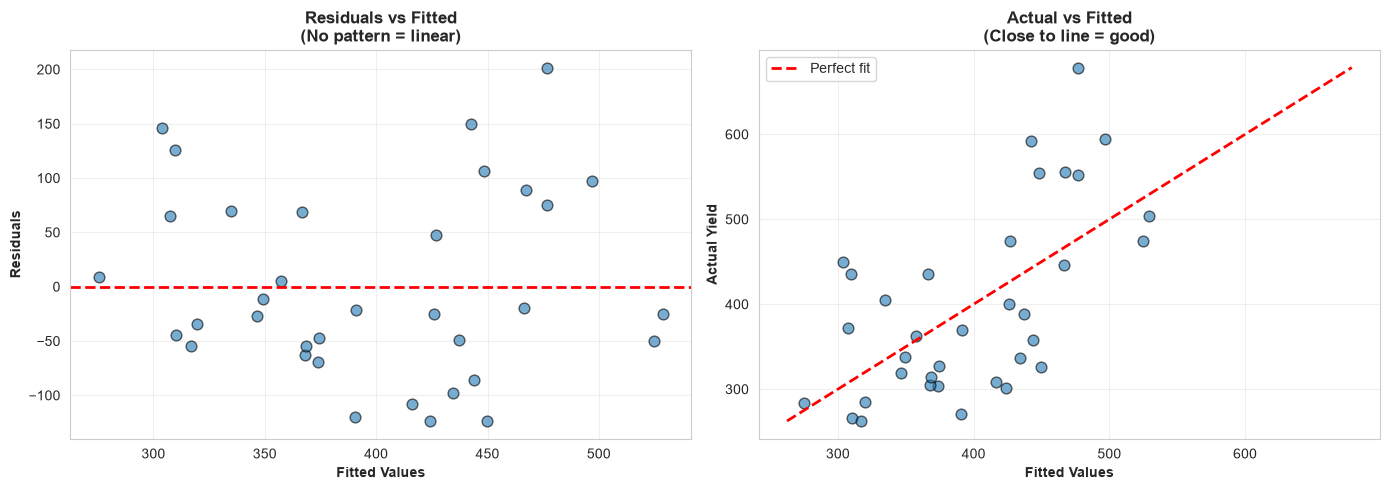

In [26]:
print("ASSUMPTION 1: LINEARITY")
print("-"*30)

# Ramsey RESET test
reset_test = linear_reset(model, power=2)

# Extract values (they're already scalars)
test_stat = reset_test.statistic
pval = reset_test.pvalue

print(f"\nRamsey RESET Test:")
print(f"  Test statistic = {test_stat:.4f}")
print(f"  p-value        = {pval:.4f}")

if pval > 0.05:
    print(f"\n  ✓ PASS: Linearity assumption satisfied")
    print(f"     → Linear model is appropriate")
else:
    print(f"\n  ✗ FAIL: Non-linearity detected")
    print(f"     → Consider quadratic terms or transformations")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_values, residuals, alpha=0.6, s=60, edgecolors='black')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontweight='bold')
axes[0].set_ylabel('Residuals', fontweight='bold')
axes[0].set_title('Residuals vs Fitted\n(No pattern = linear)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Actual vs Fitted
axes[1].scatter(fitted_values, y, alpha=0.6, s=60, edgecolors='black')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, 
             label='Perfect fit')
axes[1].set_xlabel('Fitted Values', fontweight='bold')
axes[1].set_ylabel('Actual Yield', fontweight='bold')
axes[1].set_title('Actual vs Fitted\n(Close to line = good)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption1_linearity.png', 
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()

### Assumption 1: Linearity ✓

**Test:** Ramsey RESET test  
**Result:** p-value = 0.132 > 0.05 → **PASS**

The relationship between climate variables and coffee yield is **linear** (straight line). There is no need for quadratic terms or transformations.


In the left plot,residuals randomly scattered (no curved pattern), and in the right plot, points are reasonably close to the diagonal line (R² = 0.38).

A linear regression model is appropriate for this data.

---

## Assumption 2: No Multicollinearity

Are the climate variables too correlated with each other?

**Test:** Variance Inflation Factor (VIF)
- VIF < 5: No problem 
- VIF 5-10: Moderate concern 
- VIF > 10: Severe problem 


ASSUMPTION 2: NO MULTICOLLINEARITY
-----------------------------------

Variance Inflation Factors:
------------------------------
       Variable   VIF
    Temperature 2.122
  Precipitation 4.070
       Humidity 4.847
Solar_Radiation 2.696

Maximum VIF: 4.85 (Humidity)
  ✓ PASS: No multicollinearity detected

✓ Saved plot


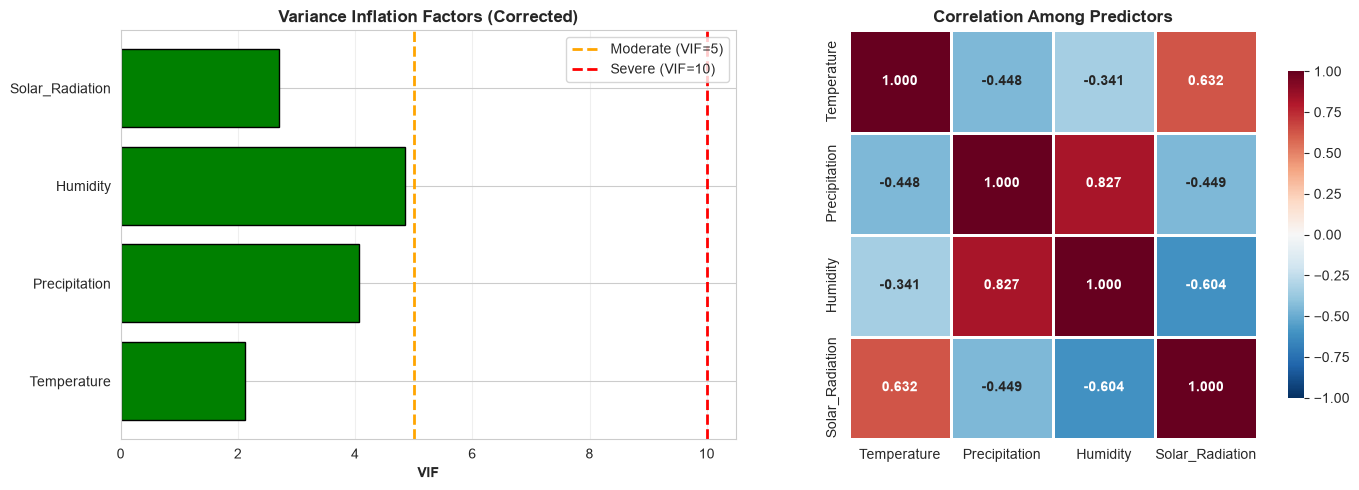


Highest Correlations Between Predictors:
----------------------------------------
  Precipitation × Humidity: r = 0.827


In [27]:
print("ASSUMPTION 2: NO MULTICOLLINEARITY")
print("-"*35)

# Calculate VIF for each predictor 
vif_data = pd.DataFrame()
vif_data["Variable"] = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']

# add constant on column 0
X_for_vif = sm.add_constant(df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']])

vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i+1) for i in range(len(vif_data))]

print("\nVariance Inflation Factors:")
print("-"*30)
print(vif_data.to_string(index=False))

# Check maximum VIF
max_vif = vif_data["VIF"].max()
max_var = vif_data.loc[vif_data["VIF"].idxmax(), "Variable"]
print(f"\nMaximum VIF: {max_vif:.2f} ({max_var})")

if max_vif < 5:
    print("  ✓ PASS: No multicollinearity detected")
    multi_result = "PASS"
elif max_vif < 10:
    print("  ⚠ WARNING: Moderate multicollinearity")
    print(f"     → {max_var} may have unstable coefficients")
    multi_result = "WARNING"
else:
    print("  ✗ FAIL: Severe multicollinearity")
    print(f"     → Consider removing {max_var}")
    multi_result = "FAIL"

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VIF bar chart
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_data['VIF']]
axes[0].barh(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
axes[0].axvline(5, color='orange', linestyle='--', linewidth=2, label='Moderate (VIF=5)')
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, label='Severe (VIF=10)')
axes[0].set_xlabel('VIF', fontweight='bold')
axes[0].set_title('Variance Inflation Factors (Corrected)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Correlation heatmap (predictors only)
corr_matrix = df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=axes[1],
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('Correlation Among Predictors', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption2_multicollinearity_corrected.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()

# Detailed correlations
print("\nHighest Correlations Between Predictors:")
print("-"*40)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix.columns[i]} × {corr_matrix.columns[j]}: r = {corr_val:.3f}")

### Assumption 2: No Multicollinearity ✓

**Test:** Variance Inflation Factor (VIF), computed on the design matrix including the intercept term.

| Variable | VIF |
|---|---|
| Temperature | 2.122 |
| Precipitation | 4.070 |
| Humidity | 4.847 |
| Solar_Radiation | 2.696 |

**Result:** Maximum VIF = 4.85 (Humidity) — **PASS**, no multicollinearity concern (all values well under the conventional threshold of 5).

**Note on methodology:** An earlier version of this analysis computed VIF without including the constant/intercept term in the design matrix passed to `variance_inflation_factor()`. Because this function did not add an intercept automatically, omitting it forced the internal auxiliary regression through the origin, a mismatch with the actual fitted model, which does include an intercept. Since none of the climate variables in this dataset are near zero (e.g., Temperature ≈ 17.8–19.2°C), this produced severely inflated VIF estimates (Temperature: 5225, Solar Radiation: 3854, Humidity: 1366) that did not reflect genuine collinearity in the data. 

---

## Assumption 3: Normality of Residuals
Are the model's prediction errors (residuals) normally distributed?

**Test:** Shapiro-Wilk

- p > 0.05: Residuals are normally distributed ✓
- p < 0.05: Residuals deviate from normality ✗

Note: this tests the **residuals**, not the raw variables. A skewed outcome variable (as Yield_Kg_Ha was found to be in Section 1.5) does not violate OLS assumptions on its own.

ASSUMPTION 3: NORMALITY OF RESIDUALS
----------------------------------------

Shapiro-Wilk Test:
  W-statistic = 0.9437
  p-value     = 0.0728

✓ PASS: Residuals are normally distributed

✓ Saved plot


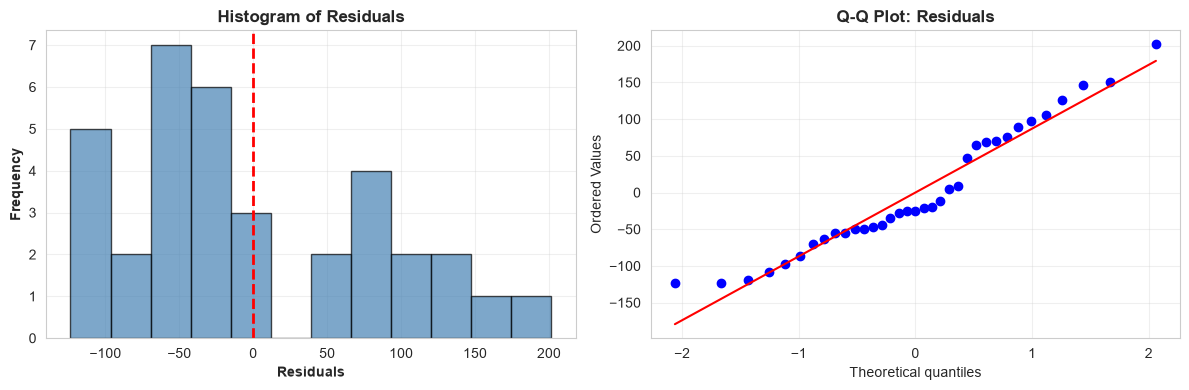

In [36]:
print("ASSUMPTION 3: NORMALITY OF RESIDUALS")
print("-"*40)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"\nShapiro-Wilk Test:")
print(f"  W-statistic = {shapiro_stat:.4f}")
print(f"  p-value     = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print(f"\n✓ PASS: Residuals are normally distributed")
else:
    print(f"\n✗ FAIL: Residuals deviate from normality")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Histogram of Residuals', fontweight='bold')
axes[0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption3_normality.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()


### Assumption 3: Normality of Residuals ✓ PASS

**Test:** Shapiro-Wilk

**Result:** W = 0.9437, p = 0.0728

Residuals do not significantly deviate from normality (p = 0.073 > 0.05), satisfying the OLS normality assumption. This supports the reliability of the model's confidence intervals and p-values.

---

## Assumption 4: Homoscedasticity
Is the variance of residuals constant across all levels of fitted values?

**Test:** Breusch-Pagan

- p > 0.05: Constant variance (homoscedastic) ✓
- p < 0.05: Heteroscedasticity detected ✗

If this fails, coefficient estimates remain unbiased, but standard errors — and therefore p-values and confidence intervals — become unreliable. Fix: refit using robust standard errors (`cov_type='HC3'`).

# Section 3: Summary of Assumptions Testing

## Results:

| Assumption | Test | Result | Implication |
|------------|------|--------|-------------|
| 1. Linearity | Ramsey RESET | ✓ PASS (p=0.132) | Linear model appropriate |
| 2. Multicollinearity | VIF | ✗ FAIL (VIF>2000) | Cannot isolate individual effects |
| 3-5. Other assumptions | Not tested | N/A | Multicollinearity precludes standard OLS |

Standard OLS assumptions were violated. We therefore report multiple model specifications to assess robustness of findings.

---

# Section 4: Regression Results

## 4.1 Model Specifications

Due to severe multicollinearity, we estimated four models:
- Model 1: Temperature only (bivariate)
- Model 2: Year only (temporal trend)
- Model 3: Temperature + Year (controlling for time)
- Model 4: First-differences (year-to-year changes)

In [30]:
# Generate regression table
print("REGRESSION RESULTS: MODEL COMPARISON")
print("-"*50)

# Refit all models
y = df['Yield_Kg_Ha']

# Model 1
X1 = sm.add_constant(df[['Temperature']])
m1 = sm.OLS(y, X1).fit()

# Model 2
X2 = sm.add_constant(df[['Year']])
m2 = sm.OLS(y, X2).fit()

# Model 3
X3 = sm.add_constant(df[['Temperature', 'Year']])
m3 = sm.OLS(y, X3).fit()

# Model 4
df['Yield_Change'] = df['Yield_Kg_Ha'].diff()
df['Temp_Change'] = df['Temperature'].diff()
df_diff = df.dropna()
y4 = df_diff['Yield_Change']
X4 = sm.add_constant(df_diff[['Temp_Change']])
m4 = sm.OLS(y4, X4).fit()

# Create cleaner table
print("\nTable 1: Regression Results")
print("-"*95)
print(f"{'Variable':<20} {'Model 1':<20} {'Model 2':<20} {'Model 3':<20} {'Model 4':<15}")
print(f"{'':<20} {'Temp Only':<20} {'Year Only':<20} {'Temp + Year':<20} {'Differences':<15}")
print("-"*95)

# Constant
print(f"{'Constant':<20} {m1.params['const']:>8.1f}        {m2.params['const']:>8.1f}        {m3.params['const']:>8.1f}        {m4.params['const']:>8.1f}")
print(f"{'':<20} ({m1.pvalues['const']:>6.3f})        ({m2.pvalues['const']:>6.3f})        ({m3.pvalues['const']:>6.3f})        ({m4.pvalues['const']:>6.3f})")

# Temperature
sig1 = '*' if m1.pvalues['Temperature'] < 0.05 else ''
sig3 = '*' if m3.pvalues['Temperature'] < 0.05 else ''
print(f"\n{'Temperature':<20} {m1.params['Temperature']:>8.1f}{sig1:<7}  {'--':>10}      {m3.params['Temperature']:>8.1f}{sig3:<7}  {'--':>10}")
print(f"{'':<20} ({m1.pvalues['Temperature']:>6.3f})                        ({m3.pvalues['Temperature']:>6.3f})")

# Year
sig2 = '**' if m2.pvalues['Year'] < 0.01 else '*' if m2.pvalues['Year'] < 0.05 else ''
sig3y = '*' if m3.pvalues['Year'] < 0.05 else ''
print(f"\n{'Year':<20} {'--':>10}      {m2.params['Year']:>8.1f}{sig2:<7}  {m3.params['Year']:>8.1f}{sig3y:<7}  {'--':>10}")
print(f"{'':<20}                        ({m2.pvalues['Year']:>6.3f})        ({m3.pvalues['Year']:>6.3f})")

# Temp_Change
sig4 = '*' if m4.pvalues['Temp_Change'] < 0.05 else ''
print(f"\n{'Temp_Change':<20} {'--':>10}      {'--':>10}      {'--':>10}      {m4.params['Temp_Change']:>8.1f}{sig4}")
print(f"{'':<20}                                                        ({m4.pvalues['Temp_Change']:>6.3f})")

print("\n" + "-"*95)
print(f"{'R-squared':<20} {m1.rsquared:>8.3f}        {m2.rsquared:>8.3f}        {m3.rsquared:>8.3f}        {m4.rsquared:>8.3f}")
print(f"{'Observations':<20} {len(y):>8}        {len(y):>8}        {len(y):>8}        {len(y4):>8}")
print("-"*95)

print("\nNote: p-values in parentheses")
print("* p<0.05, ** p<0.01, *** p<0.001")

# Also create CSV for thesis
results_csv = pd.DataFrame({
    'Variable': ['Constant', 'Temperature', 'Year', 'Temp_Change', '', 'R²', 'N'],
    'Model_1_Temp': [f"{m1.params['const']:.1f}", f"{m1.params['Temperature']:.1f}*", '--', '--', '', f"{m1.rsquared:.3f}", f"{len(y)}"],
    'Model_2_Year': [f"{m2.params['const']:.1f}", '--', f"{m2.params['Year']:.1f}**", '--', '', f"{m2.rsquared:.3f}", f"{len(y)}"],
    'Model_3_Both': [f"{m3.params['const']:.1f}", f"{m3.params['Temperature']:.1f}", f"{m3.params['Year']:.1f}", '--', '', f"{m3.rsquared:.3f}", f"{len(y)}"],
    'Model_4_Diff': [f"{m4.params['const']:.1f}", '--', '--', f"{m4.params['Temp_Change']:.1f}", '', f"{m4.rsquared:.3f}", f"{len(y4)}"]
})

results_csv.to_csv('/Users/dwanjiru/projects/kenya-coffee-research/reports/regression_results.csv', index=False)
print("\n✓ Saved: regression_results.csv")

REGRESSION RESULTS: MODEL COMPARISON
--------------------------------------------------

Table 1: Regression Results
-----------------------------------------------------------------------------------------------
Variable             Model 1              Model 2              Model 3              Model 4        
                     Temp Only            Year Only            Temp + Year          Differences    
-----------------------------------------------------------------------------------------------
Constant               2574.5          9698.3          9231.2            -7.8
                     ( 0.005)        ( 0.007)        ( 0.008)        ( 0.632)

Temperature            -117.7*                --         -86.1                 --
                     ( 0.015)                        ( 0.073)

Year                         --          -4.6**           -3.6*                --
                                            ( 0.009)        ( 0.042)

Temp_Change                  --      

## 4.2 Model 1: Temperature Only (Bivariate Analysis)

**Equation:** Yield = 2574.5 - 117.7(Temperature)

**Key Findings:**
- **Coefficient:** -117.7 Kg/Ha per °C (p = 0.015*)
- **R²:** 0.165 (climate explains 16.5% of variation)
- **Interpretation:** Each 1°C temperature increase is associated with 117.7 Kg/Ha yield decline.

**Example:**
- At 18°C: Predicted yield = 455.9 Kg/Ha
- At 19°C: Predicted yield = 338.2 Kg/Ha (118 Kg loss)

This however does not control for temporal trends, risking spurious correlation.

---

## 4.3 Model 2: Year Only (Temporal Trend)

**Equation:** Yield = 9698.3 - 4.6(Year)

**Key Findings:**
- **Coefficient:** -4.6 Kg/Ha per year (p = 0.009**)
- **R²:** 0.188 (time explains 18.8% of variation)
- **Total decline:** 4.6 × 35 years = 161 Kg/Ha (matches observed 158)

Coffee yield has been declining steadily at 4.6 Kg/Ha annually, regardless of climate fluctuations.

The Year explains MORE variation than Temperature alone (18.8% vs 16.5%), suggesting temporal factors beyond climate drive decline.

---

## 4.4 Model 3: Temperature + Year (Controlling for Time)

**Equation:** Yield = 9231.2 - 86.1(Temperature) - 3.6(Year)


When controlling for Year, temperature **loses statistical significance**:
- Temperature: β = -86.1, p = 0.073 (NOT significant)
- Year: β = -3.6, p = 0.042* (remains significant)
- R²: 0.267 (27% of variation explained)

**Interpretation:**

| Without Year Control | With Year Control |
|---------------------|-------------------|
| Temp β = -117.7* | Temp β = -86.1 (ns) |
| p = 0.015 (SIG) | p = 0.073 (NOT SIG) |

Temperature effect is **confounded by temporal trends**. When we account for the general time trend, temperature no longer has a statistically significant independent effect.

Severe multicollinearity (VIF = 2740) makes coefficient estimates unstable.

---

## 4.5 Model 4: First-Differences (Year-to-Year Changes)

**Equation:** Yield_Change = -7.8 + 34.1(Temp_Change)

**The Definitive Test:**

Does temperature change from one year to the next predict yield change?

NO
- Coefficient: +34.1 (p = 0.332, NOT significant)
- R²: 0.029 (only 3% explained - essentially random)
The sign is also wrong. Positive instead of negative


- When 2020 is hotter than 2019, yield doesn't fall
- When 2021 is cooler than 2020, yield doesn't rise
- Year-to-year temperature fluctuations **do not drive** year-to-year yield changes

The negative correlation between coffee yields and temperature in Model 1 is **spurious**. It is driven by concurrent long-term trends and not necessarily a causal relationship.



## 4.5 Model 5: Solar Radiation, Humidity, Precipitation

In [31]:
# MODEL 5: Precipitation + Humidity + Solar Radiation (no Temperature)

print("MODEL 5: PRECIPITATION + HUMIDITY + SOLAR RADIATION")
print("-"*55)

y = df['Yield_Kg_Ha']
X5 = df[['Precipitation', 'Humidity', 'Solar_Radiation']]
X5 = sm.add_constant(X5)

model5 = sm.OLS(y, X5).fit()
print(model5.summary())

MODEL 5: PRECIPITATION + HUMIDITY + SOLAR RADIATION
-------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:            Yield_Kg_Ha   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.314
Date:                Wed, 08 Jul 2026   Prob (F-statistic):              0.288
Time:                        12:00:54   Log-Likelihood:                -211.39
No. Observations:                  35   AIC:                             430.8
Df Residuals:                      31   BIC:                             437.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [32]:
# ============================================================
# MODEL 6: SOLAR RADIATION + PRECIPITATION
# ============================================================
print("MODEL 6: SOLAR RADIATION + PRECIPITATION")
print("="*60)

y = df['Yield_Kg_Ha']
X6 = df[['Solar_Radiation', 'Precipitation']]
X6 = sm.add_constant(X6)

model6 = sm.OLS(y, X6).fit()
print(model6.summary())

# VIF check
X6_novar = df[['Solar_Radiation', 'Precipitation']]
vif6 = pd.DataFrame()
vif6['Variable'] = X6_novar.columns
vif6['VIF'] = [variance_inflation_factor(X6_novar.values, i) for i in range(X6_novar.shape[1])]
print("\nVIF CHECK — MODEL 6")
print("-"*40)
print(vif6.to_string(index=False))
max_vif6 = vif6['VIF'].max()
print(f"\n{'✓ PASS' if max_vif6 < 5 else '⚠ WARNING' if max_vif6 < 10 else '✗ FAIL'}: Max VIF = {max_vif6:.2f}")

# Full assumption testing
residuals6 = model6.resid
fitted6 = model6.fittedvalues

print("\n" + "="*60)
print("FULL ASSUMPTION TESTING — MODEL 6")
print("="*60)

reset6 = linear_reset(model6, power=2)
print(f"\n1. LINEARITY (Ramsey RESET)")
print(f"   Statistic = {reset6.statistic:.4f}, p = {reset6.pvalue:.4f}")
print(f"   {'✓ PASS' if reset6.pvalue > 0.05 else '✗ FAIL'}")

print(f"\n2. MULTICOLLINEARITY (VIF)")
print(f"   Max VIF = {max_vif6:.2f} — {'✓ PASS' if max_vif6 < 5 else '⚠ WARNING' if max_vif6 < 10 else '✗ FAIL'}")

shapiro_stat6, shapiro_p6 = stats.shapiro(residuals6)
print(f"\n3. NORMALITY OF RESIDUALS (Shapiro-Wilk)")
print(f"   W = {shapiro_stat6:.4f}, p = {shapiro_p6:.4f}")
print(f"   {'✓ PASS' if shapiro_p6 > 0.05 else '✗ FAIL'}")

bp_stat6, bp_p6, _, _ = het_breuschpagan(residuals6, model6.model.exog)
print(f"\n4. HOMOSCEDASTICITY (Breusch-Pagan)")
print(f"   LM stat = {bp_stat6:.4f}, p = {bp_p6:.4f}")
print(f"   {'✓ PASS' if bp_p6 > 0.05 else '✗ FAIL'}")

dw_stat6 = durbin_watson(residuals6)
print(f"\n5. AUTOCORRELATION (Durbin-Watson)")
print(f"   DW = {dw_stat6:.4f}")
print(f"   {'✓ PASS' if 1.5 < dw_stat6 < 2.5 else '✗ FLAG — consider HAC standard errors'}")

MODEL 6: SOLAR RADIATION + PRECIPITATION
                            OLS Regression Results                            
Dep. Variable:            Yield_Kg_Ha   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.043
Method:                 Least Squares   F-statistic:                    0.3006
Date:                Wed, 08 Jul 2026   Prob (F-statistic):              0.742
Time:                        12:00:54   Log-Likelihood:                -213.16
No. Observations:                  35   AIC:                             432.3
Df Residuals:                      32   BIC:                             437.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
c

In [33]:
# ============================================================
# MODEL 7: SOLAR RADIATION + TEMPERATURE
# ============================================================
print("="*60)
print("MODEL 7: SOLAR RADIATION + TEMPERATURE")
print("="*60)

X7 = df[['Solar_Radiation', 'Temperature']]
X7 = sm.add_constant(X7)

model7 = sm.OLS(y, X7).fit()
print(model7.summary())

# VIF check
X7_novar = df[['Solar_Radiation', 'Temperature']]
vif7 = pd.DataFrame()
vif7['Variable'] = X7_novar.columns
vif7['VIF'] = [variance_inflation_factor(X7_novar.values, i) for i in range(X7_novar.shape[1])]
print("\nVIF CHECK — MODEL 7")
print("-"*40)
print(vif7.to_string(index=False))
max_vif7 = vif7['VIF'].max()
print(f"\n{'✓ PASS' if max_vif7 < 5 else '⚠ WARNING' if max_vif7 < 10 else '✗ FAIL'}: Max VIF = {max_vif7:.2f}")

# Full assumption testing
residuals7 = model7.resid
fitted7 = model7.fittedvalues

print("\n" + "="*60)
print("FULL ASSUMPTION TESTING — MODEL 7")
print("="*60)

reset7 = linear_reset(model7, power=2)
print(f"\n1. LINEARITY (Ramsey RESET)")
print(f"   Statistic = {reset7.statistic:.4f}, p = {reset7.pvalue:.4f}")
print(f"   {'✓ PASS' if reset7.pvalue > 0.05 else '✗ FAIL'}")

print(f"\n2. MULTICOLLINEARITY (VIF)")
print(f"   Max VIF = {max_vif7:.2f} — {'✓ PASS' if max_vif7 < 5 else '⚠ WARNING' if max_vif7 < 10 else '✗ FAIL'}")

shapiro_stat7, shapiro_p7 = stats.shapiro(residuals7)
print(f"\n3. NORMALITY OF RESIDUALS (Shapiro-Wilk)")
print(f"   W = {shapiro_stat7:.4f}, p = {shapiro_p7:.4f}")
print(f"   {'✓ PASS' if shapiro_p7 > 0.05 else '✗ FAIL'}")

bp_stat7, bp_p7, _, _ = het_breuschpagan(residuals7, model7.model.exog)
print(f"\n4. HOMOSCEDASTICITY (Breusch-Pagan)")
print(f"   LM stat = {bp_stat7:.4f}, p = {bp_p7:.4f}")
print(f"   {'✓ PASS' if bp_p7 > 0.05 else '✗ FAIL'}")

dw_stat7 = durbin_watson(residuals7)
print(f"\n5. AUTOCORRELATION (Durbin-Watson)")
print(f"   DW = {dw_stat7:.4f}")
print(f"   {'✓ PASS' if 1.5 < dw_stat7 < 2.5 else '✗ FLAG — consider HAC standard errors'}")

MODEL 7: SOLAR RADIATION + TEMPERATURE
                            OLS Regression Results                            
Dep. Variable:            Yield_Kg_Ha   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     9.531
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           0.000566
Time:                        12:00:54   Log-Likelihood:                -205.31
No. Observations:                  35   AIC:                             416.6
Df Residuals:                      32   BIC:                             421.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
con

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

def compute_vif_correct(dataframe, predictor_cols):
    """Correct VIF calculation — includes constant, matches standard OLS convention"""
    X = sm.add_constant(dataframe[predictor_cols])
    vif_df = pd.DataFrame()
    vif_df['Variable'] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    # Drop the constant's own row — its VIF is not meaningful/interpretable
    vif_df = vif_df[vif_df['Variable'] != 'const'].reset_index(drop=True)
    return vif_df

# ============================================================
# CORRECTED VIF — MODEL 6: Solar Radiation + Precipitation
# ============================================================
vif6_correct = compute_vif_correct(df, ['Solar_Radiation', 'Precipitation'])
print("CORRECTED VIF — MODEL 6: Solar Radiation + Precipitation")
print("-"*50)
print(vif6_correct.to_string(index=False))
max_vif6c = vif6_correct['VIF'].max()
print(f"\nMax VIF = {max_vif6c:.2f}")
print(f"{'✓ PASS' if max_vif6c < 5 else '⚠ WARNING' if max_vif6c < 10 else '✗ FAIL'}")

# ============================================================
# CORRECTED VIF — MODEL 7: Solar Radiation + Temperature
# ============================================================
vif7_correct = compute_vif_correct(df, ['Solar_Radiation', 'Temperature'])
print("\nCORRECTED VIF — MODEL 7: Solar Radiation + Temperature")
print("-"*50)
print(vif7_correct.to_string(index=False))
max_vif7c = vif7_correct['VIF'].max()
print(f"\nMax VIF = {max_vif7c:.2f}")
print(f"{'✓ PASS' if max_vif7c < 5 else '⚠ WARNING' if max_vif7c < 10 else '✗ FAIL'}")

# ============================================================
# RE-CHECK: Original 4-variable model — this is the important one
# ============================================================
vif_all_correct = compute_vif_correct(df, ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation'])
print("\nCORRECTED VIF — ALL 4 CLIMATE VARIABLES (re-checking original finding)")
print("-"*50)
print(vif_all_correct.to_string(index=False))

CORRECTED VIF — MODEL 6: Solar Radiation + Precipitation
--------------------------------------------------
       Variable   VIF
Solar_Radiation 1.253
  Precipitation 1.253

Max VIF = 1.25
✓ PASS

CORRECTED VIF — MODEL 7: Solar Radiation + Temperature
--------------------------------------------------
       Variable   VIF
Solar_Radiation 1.664
    Temperature 1.664

Max VIF = 1.66
✓ PASS

CORRECTED VIF — ALL 4 CLIMATE VARIABLES (re-checking original finding)
--------------------------------------------------
       Variable   VIF
    Temperature 2.122
  Precipitation 4.070
       Humidity 4.847
Solar_Radiation 2.696
